## DATA

In [22]:
import pandas as pd
import numpy as np

In [23]:
nodes_file_path = "../datas/nodes_indexed.csv"
edges_file_path = "../datas/edges_indexed.csv"

nodes_df = pd.read_csv(nodes_file_path)
edges_df = pd.read_csv(edges_file_path)

In [24]:
nodes_df

,name,age,occupation,monthly_income,social_status,location,label,idx
0,name-1,18,1,1769015,1,0,0.500000,0
1,name-2,43,0,1614331,0,0,0.425557,1
2,name-3,36,9,381323,0,1,0.010004,2
3,name-4,30,8,309477,1,0,0.377541,3
4,name-5,21,2,753841,3,1,0.321340,4
...,...,...,...,...,...,...,...,...
4995,name-4996,21,2,635639,2,2,0.173354,4995
4996,name-4997,26,5,951435,0,5,0.109665,4996
4997,name-4998,25,10,978375,2,0,0.377541,4997
4998,name-4999,30,10,3341422,0,0,0.081051,4998


In [25]:
edges_df

,source,target,weight,source_idx,target_idx
0,name-3,name-34,0.350857,2,33
1,name-3,name-344,0.350857,2,343
2,name-3,name-429,0.350857,2,428
3,name-3,name-541,0.350857,2,540
4,name-3,name-556,0.350857,2,555
...,...,...,...,...,...
59441,name-5000,name-4421,0.570708,4999,4420
59442,name-5000,name-4588,0.570708,4999,4587
59443,name-5000,name-4629,0.570708,4999,4628
59444,name-5000,name-4721,0.429648,4999,4720


In [26]:
X = nodes_df.drop(columns=['name', 'label']).values

In [27]:
y = nodes_df['label'].values.reshape(-1, 1)

In [28]:
N = len(nodes_df)
A = np.zeros((N, N))

for _, row in edges_df.iterrows():
    i = row['source_idx']
    j = row['target_idx']
    A[i, j] = row['weight']

In [29]:
A_hat = A + np.eye(N)

In [30]:
D = np.sum(A_hat, axis=1)
D_inv_sqrt = np.diag(1.0 / np.sqrt(D + 1e-9))

A_norm = D_inv_sqrt @ A_hat @ D_inv_sqrt

## BASE MODEL

In [31]:
import numpy as np

class ActivationFunctions:
    def __init__(self, name = "sigmoid"):
        self.name = name
    
    @property
    def get_info_actifation_pairing(self):
        return {
            'unit_step': {
                1: self.unit_step,
                0: False,
                -1: self.unit_step_deriv,
            },
            
            'sign_step': {
                1: self.sign,
                0: False,
                -1: self.sign_deriv,
            },
            
            'piece_wise_linear': {
                1: self.piece_wise_linear,
                0: True,
                -1: self.piece_wise_linear_deriv,
            },
            
            'sigmoid': {
                1: self.sigmoid,
                0: True,
                -1: self.sigmoid_deriv,
            },
            
            'hyperbolic_tanh': {
                1: self.hyperbolic_tanh,
                0: True,
                -1: self.hyperbolic_tanh_deriv,
            },
            
            'relu': {
                1: self.relu,
                0: True,
                -1: self.relu_deriv,
            },
            
            'softplus': {
                1: self.softplus,
                0: True,
                -1: self.softplus_deriv,
            },
            
            'leaky_relu': {
                1: self.leaky_relu,
                0: True,
                -1: self.leaky_relu_deriv,
            },
        }
    
    def unit_step(self, z):
        return np.where(z < 0, 0, np.where(z > 0, 1, 0.5))
    
    # doesn't exist in dl
    def unit_step_deriv(self, z):
        pass
    
    def sign(self, z):
        return np.where(z < 0, -1, np.where(z > 0, 1, 0))
    
    # doesn't exist in dl
    def sign_deriv(self, z):
        pass
    
    def piece_wise_linear(self, z):
        return np.where(
            z >= 0.5,
            1,
            np.where(
                z <= -0.5,
                0,
                z + 0.5
            )
        )
    
    def piece_wise_linear_deriv(self, z):
        return np.where(
            (z > -0.5) & (z < 0.5),
            1,
            0
        )

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
    
    def sigmoid_deriv(self, z):
        s = self.sigmoid(z)
        return s * (1 - s)
    
    def hyperbolic_tanh(self, z):
        return np.tanh(z)
    
    def hyperbolic_tanh_deriv(self, z):
        t = np.tanh(z)
        return 1 - t**2
    
    def relu(self, z):
        return (z > 0).astype(float)
    
    def relu_deriv(self, z):
        return np.where(z > 0, 1, 0)
    def leaky_relu(self, z):
        return np.where(z > 0, z, 0.01 * z)

    def leaky_relu_deriv(self, z):
        return np.where(z > 0, 1, 0.01)

    def softplus(self, z):
        return np.log1p(np.exp(z))
    
    def softplus_deriv(self, z):
        return 1 / (1 + np.exp(-z))
    

In [32]:
import numpy as np

class Conv2DTrainable:
    def __init__(
        self, 
        in_channel=3,
        out_channel=3,
        activation_func="sigmoid",
        kernel_size=3,
    ):
        self.__mod_name__ = "conv2d"
        
        self.out_channel = out_channel
        self.in_channel = in_channel
        
        self.activation_name = activation_func

        act = ActivationFunctions(activation_func)
        self.activation_pair = act.get_info_actifation_pairing[activation_func]
        self.activation = self.activation_pair[1]
        self.activation_deriv = self.activation_pair[-1]
        
        self.k_size = kernel_size
        fan_in = in_channel * self.k_size * self.k_size
        fan_out = out_channel * self.k_size * self.k_size

        limit = np.sqrt(6 / (fan_in + fan_out))
        self.__weights__ = np.random.uniform(
            -limit,
            limit,
            (out_channel, in_channel, self.k_size, self.k_size)
        )
        
        self.__bias__ = np.random.uniform(
            -limit,
            limit,
            (out_channel,)
        )
        self.__batch_cache__ = []
        
        self.__cache__ = {
            'x': None,
            'a': None,
            'z': None,
            'w': self.__weights__,
            'b': self.__bias__,
            'dl': 0,
        }
    
    @property
    def get_name(self):
        return self.__mod_name__
    
    @property
    def get_cache(self):
        return self.__cache__
    
    @property
    def get_weights(self):
        return self.__cache__['w']
    
    @property
    def get_bias(self):
        return self.__cache__['b']
    
    @property
    def get_params(self):
        return self.__cache__['w'], self.__cache__['b']
    
    def get_index_map(self, x):
        c_in, h_in, w_in = x.shape
        num_f_k, c_k, h_k, w_k = self.__weights__.shape
        
        if h_in < h_k or w_in < w_k:
            raise ValueError(
                f"Kernel size ({h_k},{w_k}) lebih besar dari input ({h_in},{w_in})"
            )
        
        max_h_index = h_in - h_k + 1
        max_w_index = w_in - w_k + 1
        
        return max_h_index, max_w_index

    def conv_2d(self, x):
        max_h_index, max_w_index = self.get_index_map(x)

        out = np.zeros((self.out_channel, max_h_index, max_w_index))

        for f in range(self.out_channel):
            kernel = self.__weights__[f]

            for row in range(max_h_index):
                for col in range(max_w_index):

                    patch = x[:, row:row+self.k_size, col:col+self.k_size]

                    out[f, row, col] = np.sum(
                        patch * kernel
                    ) + self.__bias__[f]

        return out
    
    def __single_forward(self, x):
        z = self.conv_2d(x)
        a = self.activation(z)
        
        
        self.__cache__['z'] = z
        self.__cache__['a'] = a
        
        return a
    
    def forward(self, x):
        B, C, H, W = x.shape

        outputs = []
        self.__batch_cache__ = []

        for i in range(B):
            single_x = x[i]

            self.__cache__['x'] = single_x

            a = self.__single_forward(single_x)

            self.__batch_cache__.append({
                'x': single_x,
                'z': self.__cache__['z'],
                'a': self.__cache__['a']
            })

            outputs.append(a)

        return np.stack(outputs, axis=0)
    
    def backward(self, prev_delta):
       
        B = prev_delta.shape[0]

        total_dl_dw = np.zeros_like(self.__weights__)
        total_dl_db = np.zeros_like(self.__bias__)

        delta_prev_batch = []

        for i in range(B):

            cache = self.__batch_cache__[i]

            self.__cache__['x'] = cache['x']
            self.__cache__['z'] = cache['z']

            dl_dw, dl_db, delta_prev = self.__single_backward(
                prev_delta[i]
            )

            total_dl_dw += dl_dw
            total_dl_db += dl_db
            delta_prev_batch.append(delta_prev)

        total_dl_dw /= B
        total_dl_db /= B

        self.__cache__['dl'] = (
            total_dl_dw,
            total_dl_db
        )

        return total_dl_dw, total_dl_db, np.stack(delta_prev_batch, axis=0)
    
    def __single_backward(self, prev_delta):

        x = self.__cache__['x']
        z = self.__cache__['z']
        W = self.__weights__

        C_out, C_in, K, _ = W.shape
        C_in, H_in, W_in = x.shape

        H_out = H_in - K + 1
        W_out = W_in - K + 1

        da_dz = self.activation_deriv(z)

        # delta layer ini
        delta = prev_delta * da_dz

        # gradient weight
        dl_dw = np.zeros_like(W)

        for f in range(C_out):
            for c in range(C_in):
                for i in range(K):
                    for j in range(K):

                        patch = x[c, i:i+H_out, j:j+W_out]
                        dl_dw[f, c, i, j] = np.sum(
                            patch * delta[f]
                        )

        # gradient bias
        dl_db = np.sum(delta, axis=(1,2))

        # delta untuk layer sebelumnya
        delta_prev = np.zeros_like(x)

        for f in range(C_out):
            for row in range(H_out):
                for col in range(W_out):

                    delta_prev[:, row:row+K, col:col+K] += (
                        W[f] * delta[f, row, col]
                    )

        return dl_dw, dl_db, delta_prev

    def update_step(self, dl_dw, dl_db, lr):
        self.__weights__ -= lr * dl_dw
        self.__bias__ -= lr * dl_db
        self.__cache__['w'] = self.__weights__
        self.__cache__['b'] = self.__bias__

class Conv2d:
    def __init__(self, kernel_weights, bias):
        self.kernel = kernel_weights
        self.bias = bias
        
    def conv_2d(self, x):
        pass
    
    def pass_forward(self, x):
        pass

In [33]:
import numpy as np

class NeuralNetworkTrainable:
    
    def __init__(
        self, 
        input_size=8,
        output_size=8,
        activation_func="sigmoid",
        weights=None,
        bias=None,
    ):
        
        self.__mod_name__ = "neural"

        self.activation_name = activation_func

        act = ActivationFunctions(activation_func)
        self.activation_pair = act.get_info_actifation_pairing[activation_func]

        self.activation = self.activation_pair[1]
        self.activation_deriv = self.activation_pair[-1]

        # params initialization
        if weights is not None:
            self.__weights__ = weights
            self.__input_size__ = weights.shape[0]
            self.__output_size__ = weights.shape[1]
        else:
            self.__input_size__ = input_size
            self.__output_size__ = output_size
            self.__weights__ = np.random.randn(self.__input_size__, self.__output_size__) * 0.1

        if bias is not None:
            self.__bias__ = bias
        else:
            self.__bias__ = np.random.randn(1, self.__output_size__) * 0.1

        self.__cache__ = {
            'x': None,
            'a': None,
            'z': None,
            'w': self.__weights__,
            'b': self.__bias__,
            'dl': 0
        }
        
    @property
    def get_name(self):
        return self.__mod_name__
    
    @property
    def get_cache(self):
        return self.__cache__
    
    @property
    def get_weights(self):
        return self.__cache__['w']
    
    @property
    def get_bias(self):
        return self.__cache__['b']
    
    @property
    def get_params(self):
        return self.__cache__['w'], self.__cache__['b']
    
    def forward(self, x):
        # print("input shape", x.shape)

        z = np.dot(x, self.__weights__) + self.__bias__
        a = self.activation(z)

        self.__cache__['x'] = x
        self.__cache__['z'] = z
        self.__cache__['a'] = a

        return a
    
    def backward(self, prev_delta):

        x = self.__cache__['x']
        z = self.__cache__['z']
        W = self.__weights__

        da_dz = self.activation_deriv(z)

        # delta layer ini
        delta = prev_delta * da_dz

        # gradient parameter
        # dl_dw = x.T @ delta
        dl_dw = (x.T @ delta) / x.shape[0]
        # dl_db = np.sum(delta, axis=0, keepdims=True)
        dl_db = np.sum(delta, axis=0, keepdims=True) / x.shape[0]

        # delta untuk layer sebelumnya
        delta_prev = delta @ W.T

        return dl_dw, dl_db, delta_prev

    def update_step(self, dl_dw, dl_db, lr):

        self.__weights__ -= lr * dl_dw
        self.__bias__ -= lr * dl_db

        self.__cache__['w'] = self.__weights__
        self.__cache__['b'] = self.__bias__
        

class NeuralNetwork:
    def __init__(self, weights, bias):
        self.weights = weights
        self.bias = bias
        
    def pass_forward(self, x):
        pass

## GCN MODEL RECONSTRUCTION

In [34]:
class GCNLayer:
    def __init__(self, input_dim, output_dim, activation="relu"):
        self.W = np.random.randn(input_dim, output_dim) * 0.1
        self.b = np.zeros((1, output_dim))

        act = ActivationFunctions(activation)
        self.activation = act.get_info_actifation_pairing[activation][1]
        self.activation_deriv = act.get_info_actifation_pairing[activation][-1]

        self.cache = {}

    def forward(self, X, A_norm):
        Z = A_norm @ X @ self.W + self.b
        A = self.activation(Z)

        self.cache = {
            "X": X,
            "Z": Z,
            "A_norm": A_norm
        }

        return A

    def backward(self, dA):
        X = self.cache["X"]
        Z = self.cache["Z"]
        A_norm = self.cache["A_norm"]

        dZ = dA * self.activation_deriv(Z)

        dW = X.T @ (A_norm.T @ dZ)
        db = np.sum(dZ, axis=0, keepdims=True)

        dX = A_norm @ dZ @ self.W.T

        return dW, db, dX

    def update(self, dW, db, lr):
        self.W -= lr * dW
        self.b -= lr * db

In [41]:
gcn1 = GCNLayer(X.shape[1], 16, activation="relu")
gcn2 = GCNLayer(16, 1, activation="sigmoid")

In [42]:
def forward(X):
    h1 = gcn1.forward(X, A_norm)
    out = gcn2.forward(h1, A_norm)
    return out

In [43]:
def mse_loss(pred, y):
    return np.mean((pred - y) ** 2)

def mse_grad(pred, y):
    return 2 * (pred - y) / len(y)

In [44]:
def backward(pred, y):
    grad = mse_grad(pred, y)

    dW2, db2, dH1 = gcn2.backward(grad)
    dW1, db1, _ = gcn1.backward(dH1)

    return dW1, db1, dW2, db2

In [45]:
l = []

In [46]:
for epoch in range(300):
    pred = forward(X)

    loss = mse_loss(pred, y)

    grads = backward(pred, y)

    gcn1.update(grads[0], grads[1], 0.01)
    gcn2.update(grads[2], grads[3], 0.05)

    l.append(loss)
    print(f"Epoch {epoch}, Loss: {loss}")

Epoch 0, Loss: 0.08242657312494517
Epoch 1, Loss: 0.07118483288607172
Epoch 2, Loss: 0.07010638764199326
Epoch 3, Loss: 0.06905494036940095
Epoch 4, Loss: 0.0680298815456412


Epoch 5, Loss: 0.06703060740963916
Epoch 6, Loss: 0.06605652060525055
Epoch 7, Loss: 0.06510703076135496
Epoch 8, Loss: 0.06418155501187706
Epoch 9, Loss: 0.06327951845891928
Epoch 10, Loss: 0.0624003545821661
Epoch 11, Loss: 0.06154350559767826
Epoch 12, Loss: 0.060708422769138404
Epoch 13, Loss: 0.05989456667453843
Epoch 14, Loss: 0.05910140743121837
Epoch 15, Loss: 0.05832842488207521
Epoch 16, Loss: 0.057575108745663274
Epoch 17, Loss: 0.056840958732803724
Epoch 18, Loss: 0.05612548463221386
Epoch 19, Loss: 0.055428206367556764
Epoch 20, Loss: 0.054748654028199534
Epoch 21, Loss: 0.0540863678758565
Epoch 22, Loss: 0.05344089832918138
Epoch 23, Loss: 0.05281180592826099
Epoch 24, Loss: 0.05219866128085405
Epoch 25, Loss: 0.05160104499211078
Epoch 26, Loss: 0.05101854757940524
Epoch 27, Loss: 0.05045076937380961
Epoch 28, Loss: 0.049897320409642495
Epoch 29, Loss: 0.04935782030342815
Epoch 30, Loss: 0.04883189812351232
Epoch 31, Loss: 0.04831919225149414
Epoch 32, Loss: 0.04781935023

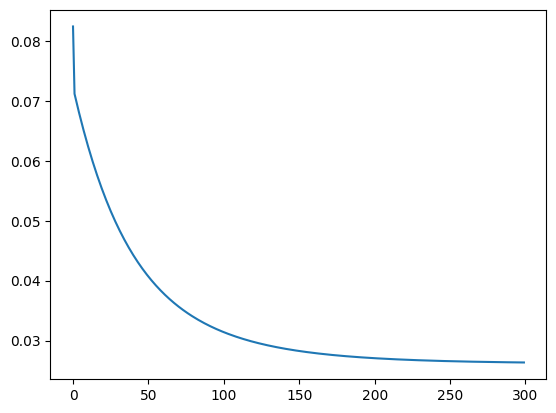

In [47]:
from matplotlib import pyplot as plt

t = [i for i in range(len(l))]

plt.plot(t, l)
plt.show()

## Model Define

In [48]:
import numpy as np

class GCNModel:
    def __init__(self, layers_config, A_norm):
        """
        layers_config: list of dict
        contoh:
        [
            {"in": 8, "out": 32, "act": "relu"},
            {"in": 32, "out": 16, "act": "sigmoid"},
            {"in": 16, "out": 1, "act": "sigmoid"},
        ]
        """
        self.__mod_name__ = "gcn_model"

        self.A_norm = A_norm

        self.layers = []
        self.__models_conf__ = []

        for cfg in layers_config:
            layer = GCNLayer(
                cfg["in"],
                cfg["out"],
                activation=cfg["act"]
            )

            self.layers.append(layer)
            self.__models_conf__.append({
                "input": cfg["in"],
                "output": cfg["out"],
                "activation": cfg["act"]
            })

    def forward(self, X):
        out = X
        for layer in self.layers:
            out = layer.forward(out, self.A_norm)
        return out

    def backward(self, pred, y):
        grad = 2 * (pred - y) / len(y)

        grads = []

        delta = grad
        for layer in reversed(self.layers):
            dW, db, delta = layer.backward(delta)
            grads.append((dW, db))

        grads.reverse()
        return grads

    def update(self, grads, lr=0.01):
        for layer, (dW, db) in zip(self.layers, grads):
            layer.update(dW, db, lr)

    def train(self, X, y, epochs=50, lr=0.01):
        for epoch in range(epochs):
            pred = self.forward(X)

            loss = np.mean((pred - y) ** 2)

            grads = self.backward(pred, y)
            self.update(grads, lr)

            print(f"Epoch {epoch} | Loss: {loss}")

    def predict(self, X):
        return self.forward(X)

In [49]:
layers_config = [
    {"in": X.shape[1], "out": 32, "act": "relu"},
    {"in": 32, "out": 16, "act": "sigmoid"},
    {"in": 16, "out": 1, "act": "sigmoid"},
]

model = GCNModel(layers_config, A_norm)

In [50]:
model.train(X, y, epochs=400, lr=0.08)

Epoch 0 | Loss: 0.1056414110084172
Epoch 1 | Loss: 0.08272890752695645
Epoch 2 | Loss: 0.07772502686953105
Epoch 3 | Loss: 0.07317150551490233
Epoch 4 | Loss: 0.06903439700514641
Epoch 5 | Loss: 0.06528007505921195
Epoch 6 | Loss: 0.06187593605087988
Epoch 7 | Loss: 0.05879089482893392
Epoch 8 | Loss: 0.055769463571109665
Epoch 9 | Loss: 0.05316395639347741
Epoch 10 | Loss: 0.05081231593957383
Epoch 11 | Loss: 0.048688918285115144
Epoch 12 | Loss: 0.046770517489914204
Epoch 13 | Loss: 0.04503612185430597
Epoch 14 | Loss: 0.04346684298285929
Epoch 15 | Loss: 0.04204573132656419
Epoch 16 | Loss: 0.040757607956612506
Epoch 17 | Loss: 0.03958889925548767
Epoch 18 | Loss: 0.03852747888036064
Epoch 19 | Loss: 0.037562519630364034
Epoch 20 | Loss: 0.036684356608603266
Epoch 21 | Loss: 0.03588436220182774
Epoch 22 | Loss: 0.03515483281371753
Epoch 23 | Loss: 0.03448888690798063
Epoch 24 | Loss: 0.03388037368733004
Epoch 25 | Loss: 0.03332379161002215
Epoch 26 | Loss: 0.03281421589415733
Epoch 

In [51]:
from pympler import asizeof

b_size = asizeof.asizeof(model.__models_conf__)
kb_size = b_size / 1024
mb_size = kb_size / 1024
print(f"size in byte: {b_size} | size in kb: {kb_size} | size in mb: {mb_size}")

size in byte: 1200 | size in kb: 1.171875 | size in mb: 0.0011444091796875


In [52]:
b_size = asizeof.asizeof(model)
kb_size = b_size / 1024
mb_size = kb_size / 1024
print(f"size in byte: {b_size} | size in kb: {kb_size} | size in mb: {mb_size}")

size in byte: 204371208 | size in kb: 199581.2578125 | size in mb: 194.90357208251953
